### Notebook to examine the results of comparing the dataset ground truth with the output of the colour finding functions.


In [1]:
## Import cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats
import itertools 
import puck.experiments.permutation_guessing as pg

In [2]:
results_dark_csv_path = pg.main(palette="dark", cal_height= "short", cal_loc="jack_cole")

../output/program_recognition_results_dark.csv
Results of testing the dark palette, have been put into a .csv in the output folder.
It can be found at: ../output/program_recognition_results_dark.csv.


In [3]:
results_csv_path = pg.main()

../output/program_recognition_results_custom.csv
Results of testing the custom palette, have been put into a .csv in the output folder.
It can be found at: ../output/program_recognition_results_custom.csv.


In [4]:
results_csv = pd.read_csv(results_csv_path)
results_csv = results_csv.drop("Unnamed: 0", axis=1)
results_csv

,key,path,found_perm,true_perm,correct,overlap
0,a,../data/images_copy/custom/michaels/high/A/cus...,afd,afd,True,3
1,a,../data/images_copy/custom/michaels/high/A/cus...,afd,afd,True,3
2,a,../data/images_copy/custom/michaels/high/A/cus...,afh,afd,False,2
3,a,../data/images_copy/custom/michaels/high/A/cus...,efd,afd,False,2
4,a,../data/images_copy/custom/michaels/high/A/cus...,afd,afd,True,3
...,...,...,...,...,...,...
235,d,../data/images_copy/custom/jack_cole/medium/D/...,fff,fff,True,3
236,d,../data/images_copy/custom/jack_cole/medium/D/...,fff,fff,True,3
237,d,../data/images_copy/custom/jack_cole/medium/D/...,fff,fff,True,3
238,d,../data/images_copy/custom/jack_cole/medium/D/...,fff,fff,True,3


Text(0.5, 1.0, 'Count of Overlaps per Permutation Key')

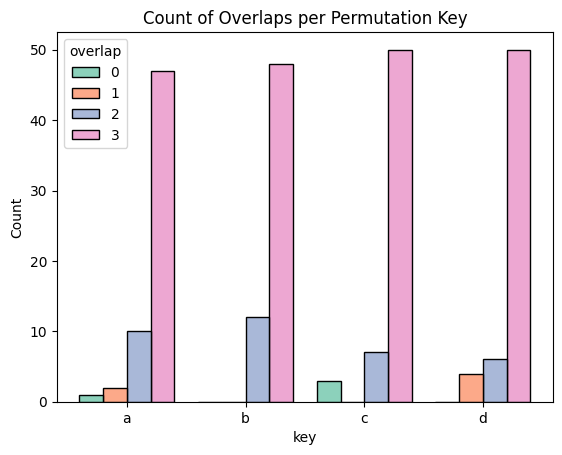

In [5]:
sns.histplot(data= results_csv, x = "key",hue="overlap",multiple="dodge", shrink=.8,palette= sns.color_palette("Set2")[:4])
plt.title("Count of Overlaps per Permutation Key")

In [6]:
results_csv_c = results_csv[results_csv["key"] == "c"]
print(results_csv_c["true_perm"].values[0])
results_csv_c["found_perm"].value_counts()

efg


found_perm
efg    50
ebg     5
gce     3
gfg     1
ehg     1
Name: count, dtype: int64

In [7]:
results_csv_d = results_csv[results_csv["key"] == "d"]
print(results_csv_d["true_perm"].values[0])
results_csv_d["found_perm"].value_counts()

fff


found_perm
fff    50
aff     3
bfa     2
faf     2
afa     1
ffa     1
afb     1
Name: count, dtype: int64

"#FE00FF",b
"#DB4F89",f

It frequently seems to get b and f confused.

In [8]:
results_csv_d = results_csv[results_csv["key"] == "d"]
print(results_csv_d["true_perm"].values[0])
results_csv_d["found_perm"].value_counts()

fff


found_perm
fff    50
aff     3
bfa     2
faf     2
afa     1
ffa     1
afb     1
Name: count, dtype: int64

In [10]:
acc_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_csv[results_csv["key"] == k]
    accuracy = round((sum(key_selection["correct"])/len(key_selection["correct"])),3)
    acc_dict.update({k: accuracy})

acc_dict

{'a': 0.783, 'b': 0.8, 'c': 0.833, 'd': 0.833}

In [11]:
close_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_csv[results_csv["key"] == k]
    close = key_selection[(key_selection["overlap"]).astype(int) >= 2]
    close_acc = round((len(close)/len(key_selection["overlap"])),3)
    close_dict.update({k: close_acc})

close_dict

{'a': 0.95, 'b': 1.0, 'c': 0.95, 'd': 0.933}

In [18]:
results_csv["path"][0]

'../data/images_copy/custom/michaels/high/A/custom_michaels_high_A_3.jpg'

In [22]:
def path_cutter(df):
    df["path2"] = df["path"].str.slice(len("../data/images_copy/custom/"),len(df["path"]))
    df[['loc','height', 'perm', 'path']] = df.path2.str.split("/",expand=True)
    df = df.drop(["path2"], axis=1)

In [23]:
path_cutter(results_csv)
results_csv = results_csv.drop(["path2"], axis=1)

In [24]:
results_csv_c = results_csv[results_csv["key"] == "c"]
results_csv_c

,key,path,found_perm,true_perm,correct,overlap,loc,height,perm
120,c,custom_michaels_high_C_1.jpg,efg,efg,True,3,michaels,high,C
121,c,custom_michaels_high_C_0.jpg,efg,efg,True,3,michaels,high,C
122,c,custom_michaels_high_C_2.jpg,efg,efg,True,3,michaels,high,C
123,c,custom_michaels_high_C_3.jpg,efg,efg,True,3,michaels,high,C
124,c,custom_michaels_high_C_4.jpg,efg,efg,True,3,michaels,high,C
125,c,custom_michaels_short_C_1.jpg,gfg,efg,False,2,michaels,short,C
126,c,custom_michaels_short_C_0.jpg,efg,efg,True,3,michaels,short,C
127,c,custom_michaels_short_C_2.jpg,efg,efg,True,3,michaels,short,C
128,c,custom_michaels_short_C_3.jpg,efg,efg,True,3,michaels,short,C
129,c,custom_michaels_short_C_4.jpg,efg,efg,True,3,michaels,short,C


In [30]:
def pivot_creator(df:pd.DataFrame):
    entries = []
    for height, loc, in itertools.product(df["height"].unique(), df["loc"].unique()):
        selection = df[(df["height"] == height) & (df["loc"] == loc)]
        overlap_avg = stats.mean(selection["overlap"])
        entries.append({"height": height, "loc": loc, "overlap_avg": overlap_avg})
    return pd.DataFrame(entries, columns=["height", "loc", "overlap_avg"])

<Axes: xlabel='height', ylabel='loc'>

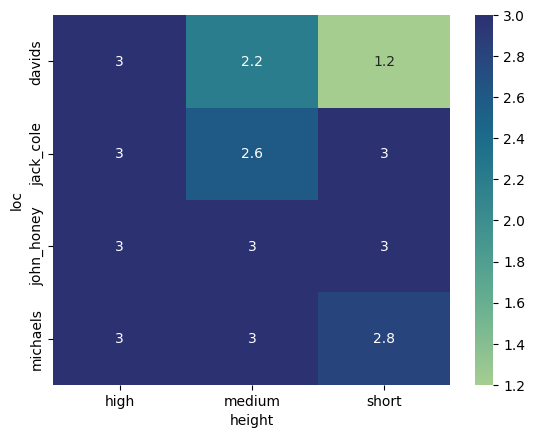

In [31]:
pivot_df = pivot_creator(results_csv_c)
results_c_pivot = (pivot_df.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_c_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))

In [32]:
results_csv_c_low= results_csv_c[results_csv_c["height"] == "short"]
results_csv_c_low["found_perm"].value_counts()

found_perm
efg    16
gce     3
gfg     1
Name: count, dtype: int64

In [33]:
results_dark_csv = pd.read_csv(results_dark_csv_path)
results_dark_csv = results_dark_csv.drop("Unnamed: 0", axis=1)
results_dark_csv

,key,path,found_perm,true_perm,correct,overlap
0,a,../data/images_copy/dark/michaels/high/A/dark_...,afd,afd,True,3
1,a,../data/images_copy/dark/michaels/high/A/dark_...,afd,afd,True,3
2,a,../data/images_copy/dark/michaels/high/A/dark_...,ahd,afd,False,2
3,a,../data/images_copy/dark/michaels/high/A/dark_...,afd,afd,True,3
4,a,../data/images_copy/dark/michaels/high/A/dark_...,afd,afd,True,3
...,...,...,...,...,...,...
235,d,../data/images_copy/dark/jack_cole/medium/D/da...,ffh,fff,False,2
236,d,../data/images_copy/dark/jack_cole/medium/D/da...,fff,fff,True,3
237,d,../data/images_copy/dark/jack_cole/medium/D/da...,dff,fff,False,2
238,d,../data/images_copy/dark/jack_cole/medium/D/da...,fff,fff,True,3


Text(0.5, 1.0, 'Count of Overlaps per Permutation Key')

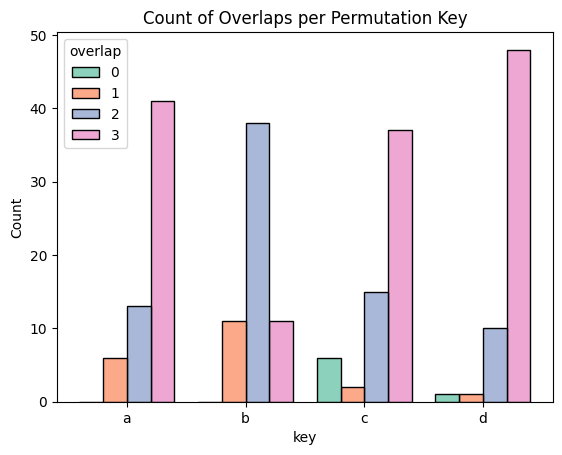

In [34]:
sns.histplot(data= results_dark_csv, x = "key",hue="overlap",multiple="dodge", shrink=.8,palette= sns.color_palette("Set2")[:4])
plt.title("Count of Overlaps per Permutation Key")

In [35]:
path_cutter(results_dark_csv)
results_dark_csv = results_dark_csv.drop(["path2"], axis=1)

In [36]:
results_dark_csv

,key,path,found_perm,true_perm,correct,overlap,loc,height,perm
0,a,dark_michaels_high_A_1.jpg,afd,afd,True,3,chaels,high,A
1,a,dark_michaels_high_A_0.jpg,afd,afd,True,3,chaels,high,A
2,a,dark_michaels_high_A_2.jpg,ahd,afd,False,2,chaels,high,A
3,a,dark_michaels_high_A_3.jpg,afd,afd,True,3,chaels,high,A
4,a,dark_michaels_high_A_4.jpg,afd,afd,True,3,chaels,high,A
...,...,...,...,...,...,...,...,...,...
235,d,dark_jack_cole_medium_D_1.jpg,ffh,fff,False,2,ck_cole,medium,D
236,d,dark_jack_cole_medium_D_0.jpg,fff,fff,True,3,ck_cole,medium,D
237,d,dark_jack_cole_medium_D_2.jpg,dff,fff,False,2,ck_cole,medium,D
238,d,dark_jack_cole_medium_D_3.jpg,fff,fff,True,3,ck_cole,medium,D


In [37]:
results_dark_csv_c = results_dark_csv[results_dark_csv["key"] == "c"]
results_dark_csv_b = results_dark_csv[results_dark_csv["key"] == "b"]
results_dark_csv_d = results_dark_csv[results_dark_csv["key"] == "d"]

In [38]:
print(results_dark_csv_c["true_perm"].values[0])
results_dark_csv_c["found_perm"].value_counts()

efg


found_perm
efg    37
ehg    11
bfg     3
gef     3
geh     2
bfe     2
ged     1
edg     1
Name: count, dtype: int64

In [39]:
print(results_dark_csv_b["true_perm"].values[0])
results_dark_csv_b["found_perm"].value_counts()

ahc


found_perm
adc    38
ahc    11
adg     9
abg     2
Name: count, dtype: int64

In [40]:
print(results_dark_csv_d["true_perm"].values[0])
results_dark_csv_d["found_perm"].value_counts()

fff


found_perm
fff    48
ffh     6
fhf     2
hhh     1
fhh     1
fdf     1
dff     1
Name: count, dtype: int64

In [41]:
acc_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_dark_csv[results_dark_csv["key"] == k]
    accuracy = round((sum(key_selection["correct"])/len(key_selection["correct"])),3)
    acc_dict.update({k: accuracy})

acc_dict

{'a': 0.683, 'b': 0.183, 'c': 0.617, 'd': 0.8}

In [42]:
close_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_dark_csv[results_dark_csv["key"] == k]
    close = key_selection[(key_selection["overlap"]).astype(int) >= 2]
    close_acc = round((len(close)/len(key_selection["overlap"])),3)
    close_dict.update({k: close_acc})

close_dict

{'a': 0.9, 'b': 0.817, 'c': 0.867, 'd': 0.967}

<Axes: xlabel='height', ylabel='loc'>

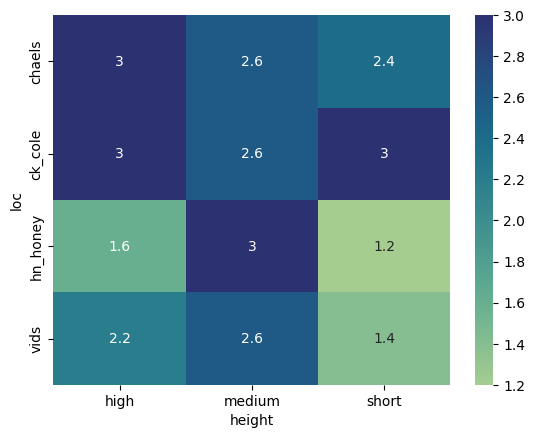

In [43]:
pivot_df_dark = pivot_creator(results_dark_csv_c)
results_dark_c_pivot = (pivot_df_dark.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_dark_c_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))

<Axes: xlabel='height', ylabel='loc'>

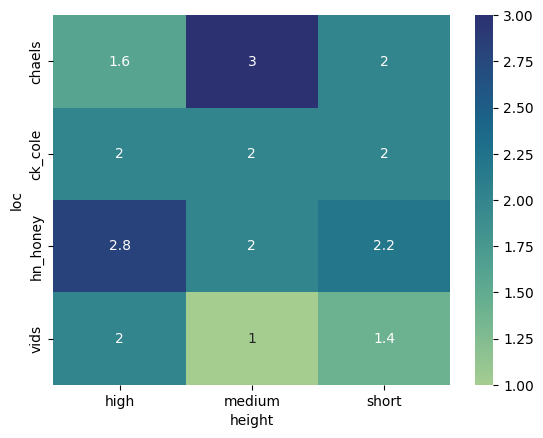

In [44]:
pivot_df_dark_b = pivot_creator(results_dark_csv_b)
results_dark_b_pivot = (pivot_df_dark_b.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_dark_b_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))